# Field cancelation

This programm uses source code from the file ```MSR_map_coil.ipynb``` created by *Chiara Weckmann*.
___
Created on 05. Jun. 2026 by Gregor Bock 

(0378 1735; ge27doc)

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bfieldtools
from bfieldtools.mesh_calculus import laplacian_matrix
from bfieldtools.mesh_impedance import resistance_matrix, self_inductance_matrix
import scipy.constants
import scipy.sparse as sp
import scipy.sparse.linalg as spl
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
import os
import glob
mu_0=scipy.constants.mu_0
pi=scipy.constants.pi

# Self made functions and classes
import Ausgelagerte_Funktionen_Versuchsauswertung as fkt    # longer plots, file readouts and other larger functions are stored in this file to save space
from Externe_Classes import Coil_Layup, Mu_material         # Properties and methods of the Coil Layup and mu_metal are stored here (e.g. meshes, B-field by Biot-Savart, Stream_function calculation)

c:\Users\grego\AppData\Local\Programs\Python\Python313\Lib\site-packages\bfieldtools\utils.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load Experiment Data

The data is loaded from a *map* directory, which has a *points* directory in which there are ```.npz``` (numpy-zip) files which hold the data for every point. The shape of the map is dertermined by the values in the ```.npz```-files as well as the total length, step_size and shift given in this block.

In [2]:
# Specify folder path for .npz and points folder (.npz file should contain L_x, L_y, L_z, step_size, shift_x, shift_y, shift_z)
folder_path_points_no_current = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\Experiments\background_01_2026-05-13_10-48-57\map\points"

# If .npz file does not hold geometric track data, specify it here
L_x = 0.800                                         # length of the mapped volume in x-direction -> Old feature, no more meaning. Kept if useful later
L_y = 0.800                                         # length of the mapped volume in y-direction -> Old feature, no more meaning. Kept if useful later
L_z = 0.400                                         # length of the mapped volume in z-direction -> Old feature, no more meaning. Kept if useful later
step_size = 0.200                                   # size of the grid steps                     -> Old feature, no more meaning. Kept if useful later

shift_x = 0                                         # shift of the mapped volume in x-direction
shift_y = 0                                         # shift of the mapped volume in y-direction
shift_z = 0                                         # shift of the mapped volume in z-direction

# Load data using the function "load_data_from_folder" from the "Ausgelagerte_Funktionen_Versuchsauswertung.py" file.
target_point_coord_exp, B_target_point_exp, _ = fkt.load_data_from_folder(folder_path_points_no_current, folder_path_points_no_current, L_x, L_y, L_z, step_size, shift_x, shift_y, shift_z)

Target point coordinates and B-field at target points both need to have dimension (n_points, 3).
  Shape of target coordinates: (75, 3)
  Shape of B-field with current at target points: (75, 3)
  Shape of B-field without current at target points: (75, 3)


## Plot the extracted Data

Plot the norm of the $B$-field of the background map in a scatter plot.

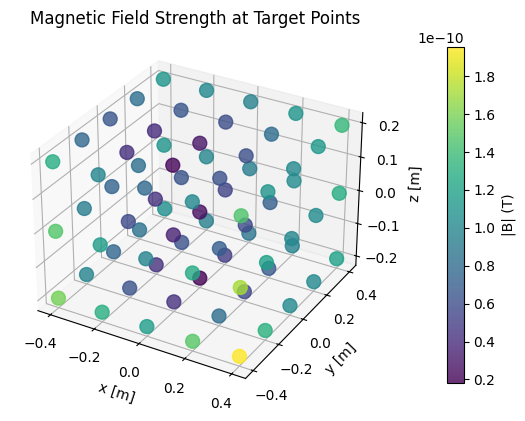

In [3]:
x = target_point_coord_exp[:,0]
y = target_point_coord_exp[:,1]
z = target_point_coord_exp[:,2]
Bnorm = np.linalg.norm(B_target_point_exp, axis=1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scat = ax.scatter(x, y, z, c=Bnorm, s=100, cmap='viridis', alpha = 0.8)

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_title('Magnetic Field Strength at Target Points')
cbar = fig.colorbar(scat, ax=ax, label='|B| (T)')
cbar.ax.set_position([0.85, 0.15, 0.03, 0.7])

plt.show()

## Data definition

In this block, all experiment data which is not extracted from the ```.npz``` -file is defined.
- MSR dimansions (including dimensions of the door and inner wood-faces)
- Parameters for coil layup
- Parameters for mesh generation
- Parameters for contour finding and smoothening
- Parameters for regularisation

**generally only SI-base units!**

In [4]:
# Inner shield (Data from CAD model "TUM - innen.step" located in P:\MSR\CAD\STEP)
shield_height = 2.341       # height of the inner most shield (2.341)
shield_width = 2.448        # width and depth of the inner most mu-metal layer (2.448)
shield_thickness = 1e-3     # thickness of the shield walls (1e-3)

# Door (Data from CAD model "TUM - innen.step" located in P:\MSR\CAD\STEP)
door_removal = False         # Boolean which states, if the door shall be seperated in the mesh or not
door_width = 0.95           # (width of the door)
door_height = 2.004         # (height of the door)
door_offset_x = 0.2375      # (distance from door frame to right wall)
door_floor_offset = 0.0     # (distance from door frame to floor)

# Inner wood structure (Data from CAD model "TUM - innen.step" located in P:\MSR\CAD\STEP)
height_inner_wood = 2.211   # height of the inner wooden structure
width_inner_wood = 2.356    # width of the inner wooden structure
depth_inner_wood = 2.356    # depth of the inner wooden structure

# Coil Layout
coil_plane_dist_to_origin_x = width_inner_wood/2    # distance of the coil plane to the origin in x-direction
coil_plane_dist_to_origin_y = depth_inner_wood/2    # distance of the coil plane to the origin in y-direction
coil_plane_dist_to_origin_z = height_inner_wood/2   # distance of the coil plane to the origin in z-direction
useable_length_x = width_inner_wood - 0.1           # useable length, on which the coils can be placed, in x-direction
useable_length_y = depth_inner_wood - 0.1           # useable length, on which the coils can be placed, in y-direction
useable_length_z = height_inner_wood - 0.1          # useable length, on which the coils can be placed, in z-direction
n_windings = 10                                     # number of windings per coil (only to initialise coil layup)
current = 0.001                                     # current in A flowing through the coils (only to initialise coil layup)

# Mesh parameters (chosen due to computation performance):
interpolate_B_exp = False                       # Determines if the input map is linear interpolated (This increases the amount of target points and makes the mesh homogeneouse)
B_exp_refined = 21                              # number of interpolation points of the experimental measurement of the B-field in the direction where the measurement volume is largest (For all evaluation - plots to work, choose an odd number)
grid_quality_coilplane = 10                     # number of initial nodes in one direction of the coil-plane (coarsened mesh) (12)
grid_quality_mu_metal = grid_quality_coilplane  # number of initial nodes in one direction of the mu_material plane (12)
Steps = 20                                      # number of steps in the streamfunction, which define the current in the wires (20)
refinement_factor=400                           # number of gridpoints for a refined grid in which the contourlines (wire-paths) are described
fft_keep = None                                 # None if automatic formular or manually specified number of harmonic modes to keep when smoothening the contour lines
fft_alpha = 0.025                               # weight for automatic formular to determine the number of harmonic modes to keep when smoothening the contour lines (0.2 means 20% of the points are kept)
fft_resample = 200                              # number of points to use when resampling the contour lines (preperation for smoothening)

# Regularisation
lam_lap  = 1e-16                                # Laplace penalty   -> promotes mathematically smooth stream function (small curvatue of stream function) -> EXTREMELY sensitive!!! choose YERY small values (1e-16)
# lam_ohm  = 0                                  # Ohmic penalty     -> promotes short wire lengths 
# lam_ind  = 0                                  # Inductance penalty-> promotes low inductance coils (which are easier to drive and less prone to parasitic capacitances)

# Experiment setup
spacing = 0.06                                  # Distance between two points which can be connected in the MSR (Experiment discretization)

## Bore-hole-removal

(not working at the moment...work in progress...maybe)

In [5]:
# Abmaße der Bohrungen, an denen die Platten aufgehängt werden könntren

offset_x = coil_plane_dist_to_origin_x  # making names shorter
offset_y = coil_plane_dist_to_origin_y
offset_z = coil_plane_dist_to_origin_z

# Supports (Data from CAD model "TUM - innen.step" located in P:\MSR\CAD\STEP)
support_removal = False      # Boolean which states, if the supports shall be seperated in the mesh or not
support_diameter = 0.030    # diameter of the supports

pos_supports_sides = np.array([[-750, 937.5], [0, 937.5], [+750, 937.5],
                                [-750, 625], [0, 625], [+750, 625],
                                [-750, 125], [0, 125], [+750, 125],
                                [-750, -125], [0, -125], [+750, -125],
                                [-750, -625], [0, -625], [+750, -625],
                                [-750, -937.5], [0, -937.5], [+750, -937.5]]) * 1e-3
# Rechte Wand:
offset_x_array = np.full(shape=pos_supports_sides.shape[0], fill_value=offset_x)
offset_y_array = np.full(shape=pos_supports_sides.shape[0], fill_value=offset_y)
pos_supports_right = np.column_stack([+offset_x_array, pos_supports_sides[:, 0], pos_supports_sides[:, 1]])
# Linke Wand:
pos_supports_left = np.column_stack([-offset_x_array, pos_supports_sides[:, 0], pos_supports_sides[:, 1]])
# Hintere Wand: [x, y=offset, z]
pos_supports_front = np.column_stack([pos_supports_sides[:, 0], +offset_y_array, pos_supports_sides[:, 1]])

pos_supports_back = np.array([[+970.5, -offset_y, 865], [-39.5, -offset_y, 865], [-750, -offset_y, 937.5],
                                [+970.5, -offset_y, 625], [-39.5, -offset_y, 625], [-750, -offset_y, 625],
                                [+970.5, -offset_y, 125], [-39.5, -offset_y, 125], [-750, -offset_y, 125],
                                [+970.5, -offset_y, -125], [-39.5, -offset_y, -125], [-750, -offset_y, -125],
                                [+970.5, -offset_y, -625], [-39.5, -offset_y, -625], [-750, -offset_y, -625],
                                [+970.5, -offset_y, -965], [-39.5, -offset_y, -965], [-750, -offset_y, -937.5]]) * 1e-3
pos_supports_top = np.array([[850, 750, +offset_z], [850, 0, +offset_z], [850, -750, +offset_z],
                                [750, 1000, +offset_z], [750, 625, +offset_z], [750, 125, +offset_z], [750, -125, +offset_z], [750, -625, +offset_z], [750, -1000, +offset_z],
                                [625, 750, +offset_z], [625, 0, +offset_z], [625, -750, +offset_z],
                                [125, 750, +offset_z], [125, 0, +offset_z], [125, -750, +offset_z],
                                [0, 1000, +offset_z], [0, 625, +offset_z], [0, 125, +offset_z], [0, -125, +offset_z], [0, -625, +offset_z], [0, -1000, +offset_z],
                                [-125, 750, +offset_z], [-125, 0, +offset_z], [-125, -750, +offset_z],
                                [-625, 750, +offset_z], [-625, 0, +offset_z], [-625, -750, +offset_z],
                                [-750, 1000, +offset_z], [-750, 625, +offset_z], [-750, 125, +offset_z], [-750, -125, +offset_z], [-750, -625, +offset_z], [-750, -1000, +offset_z],
                                [-850, 750, +offset_z], [-850, 0, +offset_z], [-850, -750, +offset_z]])

## Interpolate B-field

To obtain more Data from the the measured field, additional data points are added by linearly interpolating between the already existing ones. This can also be used to make the mesh more homogeneouse if the map was inhomogeneous before (meaning the location of the measurement points, not their B-field values). *Note* that the B-field will only be interpolated and not extrapolated. Meaning outer boaders of the map will stay the same. This cell will only be executed, if ```interpolate_B_exp``` is set to ```True```.

In [6]:
if interpolate_B_exp:

    target_point_coord_exp, B_target_point_exp = fkt.interpolate_cartesian_grid(target_point_coord_exp, B_target_point_exp, B_exp_refined)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    scat = ax.scatter(target_point_coord_exp[:, 0], target_point_coord_exp[:, 1], target_point_coord_exp[:, 2], c=np.linalg.norm(B_target_point_exp, axis = 1), s=10, cmap='viridis', alpha = 0.8)

    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    ax.set_title('Interpolated B-field from Experiment')
    cbar = fig.colorbar(scat, ax=ax, label='|B| (T)')
    cbar.ax.set_position([0.85, 0.15, 0.03, 0.7])

    plt.show()

## Create Coil_Layup instance
Create instance to the class Coil_Layup to later create a mesh on this surface. Since this class is also used in another programm, coil_diameter = 0; x_dist = 2; y_dist = 2; z_dist = 2 are set, such that no problems in this programm should occour. These inputs are not relevant for this programm.

In [7]:
# Initialise coil layup class
Coils = Coil_Layup(coil_diameter = 0, x_dist = 2, y_dist = 2, z_dist = 2, n_windings = n_windings, current = current, coil_plane_dist_to_origin_x = coil_plane_dist_to_origin_x, coil_plane_dist_to_origin_y = coil_plane_dist_to_origin_y, coil_plane_dist_to_origin_z = coil_plane_dist_to_origin_z, usable_length_x = useable_length_x, usable_length_y = useable_length_y, usable_length_z = useable_length_z)

## Create mesh of coil plane

Creates a triangular mesh on each of the surfaces, where coils are placed (not necessarily the walls of the MSR). Afterwards, the bore holes which should hold the coil Layup are removed from the mesh. This will only be executed if ```support_removal``` is ```True```.

In [8]:
Coils.create_mesh(grid_quality_coilplane, door_removal, door_width, door_height, door_floor_offset, door_offset_x)      # Create a triangular mesh on the plane where the coils are located

Coils.remove_support_holes(pos_supports_left, pos_supports_right, pos_supports_front, pos_supports_back, pos_supports_top, support_diameter, support_removal)  # Remove the holes for the supports from the mesh

# # Plot the mesh in 2D
# x = Coils.mesh_right.vertices[:, 0]
# y = Coils.mesh_right.vertices[:, 1]
# z = Coils.mesh_right.vertices[:, 2]
# faces = Coils.mesh_right.faces

# triang = mtri.Triangulation(y, z, faces)
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.triplot(triang, color='k', linewidth=0.8)
# ax.set_aspect('equal')
# ax.set_title('XZ wall with door')
# plt.show()

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# inner_idx=bfieldtools.utils.find_mesh_boundaries(Coils.total_planes)
# inner_vertex_idx=inner_idx[0]
# for idx in inner_vertex_idx:
#     boundary=Coils.total_planes.vertices[idx]
#     ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')
# #fig.subplots_adjust(left=0.0, right=30.0, bottom=0.0, top=1.0)
# verts=Coils.total_planes.vertices
# ax.scatter(verts[:,0],verts[:,1],verts[:,2],alpha=0.1,label='coil planes')
# ax.scatter(target_point_coord_exp[:,0],target_point_coord_exp[:,1],target_point_coord_exp[:,2],label='MSR Map Points')
# # Axis labels
# ax.set_xlabel('x [m]')
# ax.set_ylabel('y [m]')
# ax.set_zlabel('z [m]')
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Beispiel: typische Dreieckgröße auf der linken Wand
# verts_left = Coils.mesh_left.vertices
# faces_left = Coils.mesh_left.faces

# # Abstand zwischen irgendwelchen vertices eines Face
# dists = np.sqrt(
#     (verts_left[faces_left[:, 0]] - verts_left[faces_left[:, 1]])**2 +
#     (verts_left[faces_left[:, 0]] - verts_left[faces_left[:, 2]])**2 +
#     (verts_left[faces_left[:, 1]] - verts_left[faces_left[:, 2]])**2
# )
# edge_lengths = np.sqrt(dists)

## Shield meshing class

To account for the $\mu$-metal a meshed geometry accourding to the specified geometric data can be created by calling the class ```Mu_material``` from the file **Externe_Classes.py**. This will output a triangular mesh of the $\mu$-metal surface.

This block also plots the mesh (of one planar surface), the mesh boundaries (should be an empty plot) as well as the cells in 3D just as in the original programm.

In [9]:
mu_grid = Mu_material(grid_quality_mu_metal, shield_height, shield_width, shield_thickness)          # Create a triangular mesh at the plane where the inner shell of mu-metal is located

# # Plot
# # plot meshboundaries of the mu-metal
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# inner_vertex_idx_shield = mu_grid.inner_idx[0]
# for idx in inner_vertex_idx_shield:
#     boundary=mu_grid.total_shield.vertices[idx]
#     ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

# # plot vertices
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# verts_shield = mu_grid.total_shield.vertices
# ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.5)

# # plot vertices of the shield and points inside the shield
# points_inside = mu_grid.total_shield.vertices - mu_grid.thickness * mu_grid.total_shield.vertex_normals
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.3)
# ax.scatter(points_inside[:,0],points_inside[:,1],points_inside[:,2],alpha=0.3)

Watertight: True
Euler number: 2
Boundary edges should have length = 0! They have length = 0


## Finding the Coupling-matrix $C_{ij}$

**Prerequisites**:

In the calculatetion we are using the stream function $\psi(r)$ which can be closely linked to the surface current with
\begin{gather}
    {j}({r}) = \nabla_\parallel \psi(r) \times n(r)\\
    \psi(r) - \psi(r_0) = \int_{r_0}^r j(r') \cdot (\text{d}l \times n')
\end{gather}
where current_density $j$, normal-vector $n$ and position $r$ are vectors in 3D and the stream function $\psi$ is a scalar quantity.

In the programm we define the stream function as the sum of as weight $s_i$ times a hat-function $h_i$ at every vertex $i$. The hat function is a simple function which is 1 at the vertex $i$ and zero at all other verteces. Between the verteces it gets interpolated linearly!

\begin{equation}
    \psi(r) = \sum_{i=0}^{\text{number of vertices}} s_i \cdot h_i(r)
\end{equation}

Following this we will express all obperations with the stream function $\psi$ as functions of its weights $s_i$!

**Workflow of the program**:
- Calculate scalar potential matrices $U_{coil}$ and $U_{shield}$:
\begin{equation}
    \Phi(r_i) = \sum_{j=i}^{N_{vertices}} U_{ij, \text{coil}}s_{j, \text{coil}} = -\sum_{j=i}^{N_{vertices}} U_{ij, \text{shield}}s_{j, \text{shield}}
\end{equation}
where $\Phi(r_i)$ is the scalar potential, $s_j$ is the stream function at vertex $j$ and U_{ij} is the scalar potential matrix. (See paper: Magnetic field modeling with surface currents. Part II. Implementation and usage of bfieldtools; Equation (12))

- From scalar potential matrices $U_{ij}$ compute coil-shiel-coupling matrix $M_{ij}$
\begin{gather}
    U_{shield} \cdot M_{tot\_shield} = U_{coils} \\
    s_{\text{shield}} = - U_{\text{shield}}^{-1} \cdot U_{\text{coil}} \cdot s_{\text{coil}} = M_{tot\_shield} \cdot s_{\text{coil}}
\end{gather}

- Calculate the magnetic coupling matrix $C_{ij\alpha}$ of the $\mu$-metal in all three space directions
\begin{align}
    B_{\alpha,\text{shield}}(r_k) = \sum_{i=1}^{N_{vertices}} C_{ki\alpha,\text{shield}}s_{i,\text{shield}} && \alpha \in \{x,y,z\}
\end{align}
where $B_{\alpha,\text{shield}}(r_k)$ is the magnetic field at $r_k$ in direction $\alpha$ produced by the shield, and $s_{i,\text{shield}}$ is the streamfunction in the shield at vertex $i$.

- Calculate the magnetic coupling matrix $C^*_{ij\alpha,\text{shield}}$ of the $\mu$-metal as if it was caused by the coil-plane (change of reference)
 \begin{equation}
    C^*_{\alpha,\text{shield}} = C_{\alpha,\text{shield}} \cdot M_{tot\_shield}
 \end{equation}

- Calculate the magnetic coupling matrix $C^*_{ij\alpha,\text{coil}}$ of the coils
\begin{align}
    B_{\alpha,\text{coil}}(r_k) = \sum_{i=1}^{N_{vertices}} C_{ki\alpha,\text{coil}}s_{i,\text{coil}} && \alpha \in \{x,y,z\}
\end{align}
where all quantities are analog to those of the shield case.

- At the boundaries of the coil plane, it holds that in any case no current can flow over the edge, resulting in a streamfunction which is constant and can be set to zero (gauge). (**Note**, that since the shield of the MSR is connected at the edges, allowing current-flow over the edge. Therefore the edges of the shield are no boundaries! This is done in the class method

- Optain the total coupling matrix $C_{ij\alpha, \text{total}}$ of both coils and shield by adding both together
\begin{equation}
    C_{ij\alpha, \text{total}} = C^*_{ij\alpha,\text{shield}} + C_{ij\alpha,\text{coil}}
\end{equation}

- Reshape the coil coupling matrix $C^*_{ij\alpha,\text{coil}}$ and the total coupling matrix $C_{ij\alpha, \text{total}}$ as well as the predicted $B$-field due to the coils alone to better use it later on (shape: N, 3, M -> 3N, M)



In [10]:
# Run these few lines in extra code block since they take a while to execute!
# Scalar-Potential Coupling Matrix U_{ij} (only dependent on geometrical data of meshes)
    # mu-material
U_coupling_shield_inside = bfieldtools.mesh_magnetics.scalar_potential_coupling(mu_grid.total_shield, mu_grid.points_inside)
    # Coils
U_coupling_coils_inside = bfieldtools.mesh_magnetics.scalar_potential_coupling(Coils.total_planes, mu_grid.points_inside)

# total shield coupling which links the coil plane to the shield plane U_shield * M = U_coil
Coil_Shield_coupling = np.linalg.solve(U_coupling_shield_inside, U_coupling_coils_inside)

# B-field coupling matrix C_shield of the shield alone (only dependent on gemetrical data of mu-mesh and target point coordinates)
Coupling_shield = bfieldtools.mesh_magnetics.magnetic_field_coupling(mu_grid.total_shield, target_point_coord_exp)

# B-field coupling matrix C*_shield of the shield alone, seen as a secondary source from the coil plane perspective C*_shield = C_shield * M
secondary_Coupling_shield = np.tensordot(Coupling_shield, Coil_Shield_coupling, axes=([2],[0]))

# B-field coupling matrix C_coil of the coil plane (only dependent on gemetrical data of coil-mesh and target point coordinates)
Coupling_coil = bfieldtools.mesh_magnetics.magnetic_field_coupling(Coils.total_planes, r = target_point_coord_exp)

Computing scalar potential coupling matrix, 7778 vertices by 7778 target points... took 58.51 seconds.
Computing scalar potential coupling matrix, 8214 vertices by 7778 target points... took 58.19 seconds.
Computing magnetic field coupling matrix, 7778 vertices by 75 target points... took 0.37 seconds.
Computing magnetic field coupling matrix, 8214 vertices by 75 target points... took 0.38 seconds.


In [11]:
# # Note: Not sure if this is correct! One should be able to remove this!
# inner_idx = bfieldtools.utils.find_mesh_boundaries(Coils.total_planes)
# inner_vertex_idx = inner_idx[0]
# for idx in inner_vertex_idx:
#     Coupling_coil[:, :, idx] = 0

# Combined coupling matrix C_total which incorporates the effect of the shield as a secondary source and the coil plane as a primary source
total_Coupling = Coupling_coil + secondary_Coupling_shield # Note: The minus here is directly from the equation in the paper (see markdown)

# Suppose C_coil has shape (N, 3, M) (N...number of target points, M...number of vertices in coil plane)
N, _, M = Coupling_coil.shape
Coupling_coil_flat = Coupling_coil.reshape(3 * N, M)

# Suppose C_tot has shape (N, 3, M) (N...number of target points, M...number of vertices in coil plane)
N, _, M = total_Coupling.shape
total_Coupling_flat = total_Coupling.reshape(3 * N, M)

# Suppose B_predicted has shape (N, 3) (N...number of target points)
N, _ = B_target_point_exp.shape
B_target_point_exp_flat = B_target_point_exp.reshape(3 * N)

# Debug
print(f'Shapes of the different matrices:\n   U_coupling_shield_inside: {U_coupling_shield_inside.shape}\n   U_coupling_coils_inside: {U_coupling_coils_inside.shape}\n   Coil_Shield_coupling: {Coil_Shield_coupling.shape}\n   B_coupling_shield: {Coupling_shield.shape}\n   secondary_Coupling_shield: {secondary_Coupling_shield.shape}\n   Coupling_coil: {Coupling_coil.shape}\n   total_Coupling: {total_Coupling.shape}\n   Coupling_coil_flat: {Coupling_coil_flat.shape}\n   total_Coupling_flat: {total_Coupling_flat.shape}')

Shapes of the different matrices:
   U_coupling_shield_inside: (7778, 7778)
   U_coupling_coils_inside: (7778, 8214)
   Coil_Shield_coupling: (7778, 8214)
   B_coupling_shield: (75, 3, 7778)
   secondary_Coupling_shield: (75, 3, 8214)
   Coupling_coil: (75, 3, 8214)
   total_Coupling: (75, 3, 8214)
   Coupling_coil_flat: (225, 8214)
   total_Coupling_flat: (225, 8214)


## Plot streamfunction of coil

Here, we want to derive the streamfunction from:
\begin{equation}
    \mathbf{B} = \mathbf{C} \cdot \mathbf{s}
\end{equation}
Sadly, $\mathbf{C}$ is in general not a square matrix and not invertable. Therefore we can solve the problem using the numpy least square algorythm which searches for the solution $s_{LQ}$ which minimises:
\begin{equation}
    \min_{s}||Cs_{LQ} - B||_2^2
\end{equation}

However, this may lead to an overfitting of the actual streamfunction. In an effort to decrese the error which is generated by our solution, we accept fast and unphysical changes in the streamfunction. To solve this issue, we introduce a *Tikhonov* (Laplace) regularisation. This regularisation uses the *Laplace Operator* $\text{L}$, which can be seen as second derivative of our scalar field. It is added in the cost function to penalise fast changes in the gradient of the streamfunction and thereby reduces overfitting. The improved cost-function looks like
\begin{equation}
    \min_{s}||Cs_{LQ} - B||_2^2 + \lambda_{L}||\text{L} s||_2^2 + \lambda_{\Omega} s^T R s + \lambda_{\mathcal{L}} s^T \mathcal{L} s
\end{equation}
where $\lambda_{L}$, $\lambda_{\Omega}$ and $\lambda_{\mathcal{L}}$ are the constant weighing factors which prioritise smoothnmess, short wire length and low enegry stored in magnetic fields due to self_inductance. Alternatively the problem can be formulated as
\begin{equation}
    \min_s \left\lVert \begin{bmatrix} C \\ \sqrt{\lambda_{L}}L \\ \sqrt{\lambda_{\Omega}}R^{1/2} \\ \sqrt{\lambda_{\mathcal{L}}}\mathcal{L}^{1/2} \end{bmatrix} s - \begin{bmatrix} B \\ 0 \\ 0 \\ 0 \end{bmatrix}\right\rVert_2^2
\end{equation}

The problem of minimizing this function is soved by setting the first derivative to zero. Therefore the square terms need to be expanded. The derivative and subsequent equation is
\begin{equation}
    (C^TC + \lambda_{L} L^T L + \lambda_{\Omega} R + \lambda_{\mathcal{L}} \mathcal{L}) s = C^T B_{target}
\end{equation}

For the discretization of these operators see **bfieldtools documentation**! *Note* that in this program we will only use regularisation with the Laplace-Operator, since we do not want to optimize the coil layup, tackle the problem of an ill-conditioned problem, making the inverse problem arbituary.

*Note*, that for increased computational performance, sparse matrices are used! If the *self_inductance* is omitted, this leads to significant performance increse!

Also *note* that the streamsfunction needs to be zero at all boundaries!!!

Total vertices: 8214
Boundary vertices: 1173


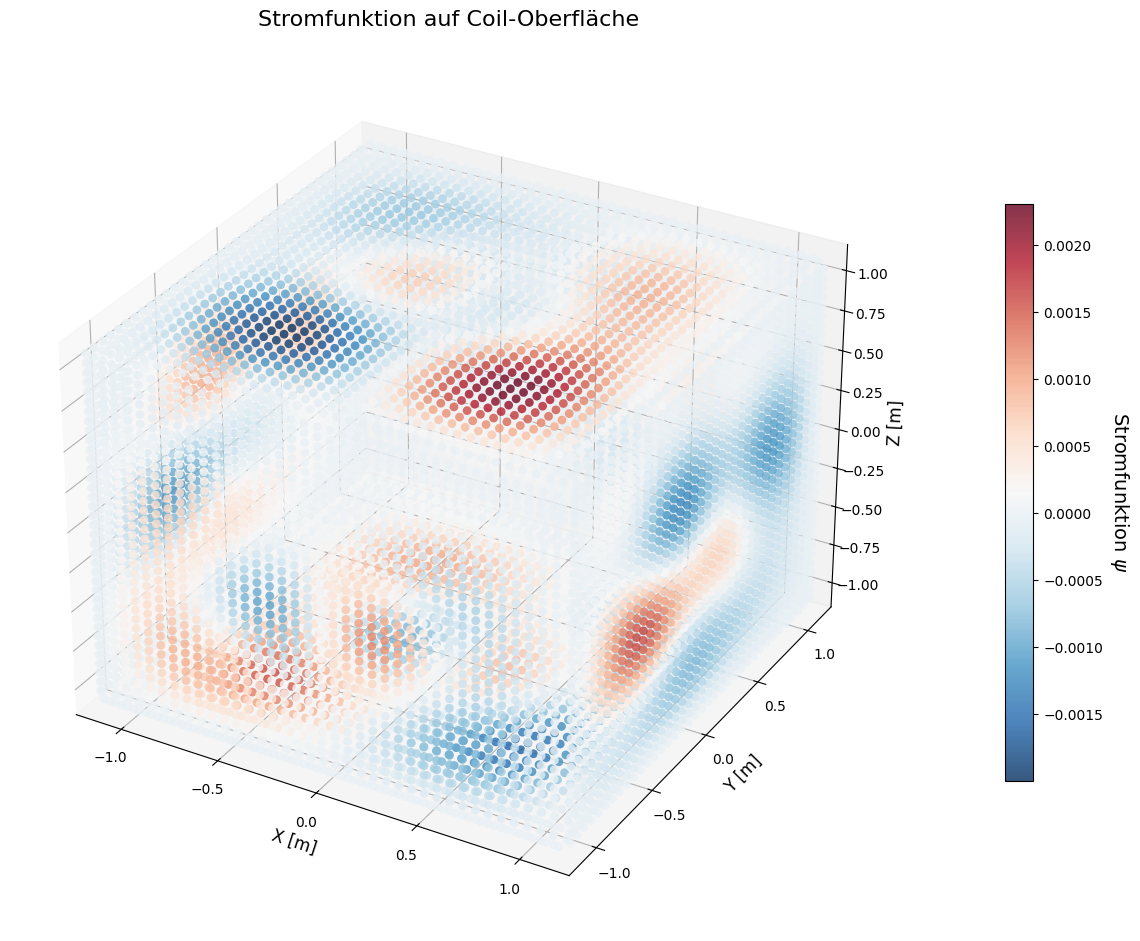

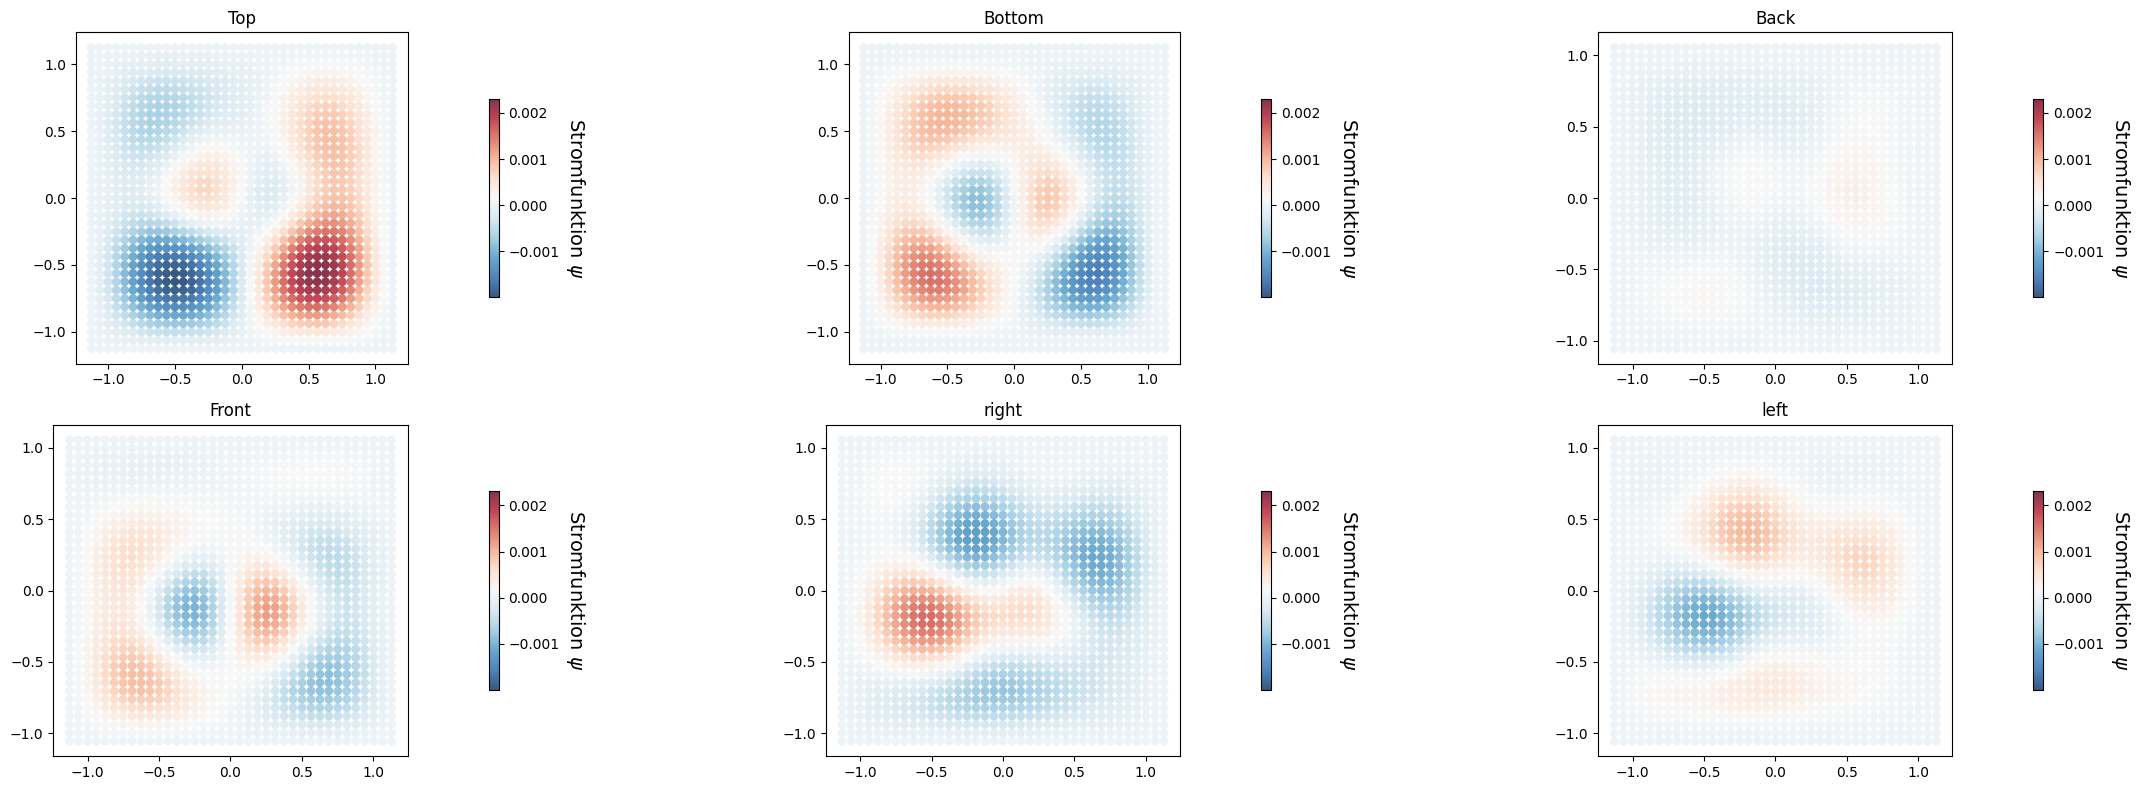

In [12]:
# 1. Mesh and MeshConductor
# cube_mesh: trimesh.Trimesh with 6 disconnected planar faces
coil = Coils.mesh_conductor                                         # special Trimesh object

# 2. Find boundary edges (edges that belong to only one face)
boundary_edge_indices = Coils.coil_plane_boundaries
boundary_edges = coil.mesh.edges[boundary_edge_indices]
boundary_vertices = np.unique(boundary_edges.flatten())

print(f"Total vertices: {len(coil.mesh.vertices)}")
print(f"Boundary vertices: {len(boundary_vertices)}")

# Create mask for interior vertices
is_interior = np.ones(len(coil.mesh.vertices), dtype=bool)
is_interior[boundary_vertices] = False
interior_vertices = np.where(is_interior)[0]


# 3. Regularization operators
# Keep all matrices sparse for improved performance!
Coupling_coil_flat_sparse = sp.csr_matrix(Coupling_coil_flat)                           # made sparse
L_sparse = laplacian_matrix(coil.mesh)                                                  # Already sparse
# R_sparse = resistance_matrix(coil.mesh, sheet_resistance=1.0)                         # Already sparse
# L_ind_sparse = self_inductance_matrix(coil.mesh, quad_degree=3, approx_far=True)      # Already sparse

# 4. Solve normal equations with all three penalties
A = Coupling_coil_flat_sparse.T @ Coupling_coil_flat_sparse
A += lam_lap * (L_sparse.T @ L_sparse)                                                  # Add regularisation based on mathematical condition, avoiding fast changes in Stream-function
# A += lam_ohm * R_sparse                                                               # Add regularisation based on ohmic efficiency. lam_ohm needs to be defined
# A += lam_ind * L_ind_sparse                                                           # Add regularisation based on inductive efficiency. lam_ind needs to be defined

b = Coupling_coil_flat_sparse.T @ B_target_point_exp_flat

# 5. Extract submatrices for interior DOFs only
A_interior = A[np.ix_(interior_vertices, interior_vertices)]
b_interior = b[interior_vertices]

# 6. Solve for interior stream function values
stream_func_interior = spl.spsolve(A_interior, b_interior)

# 7. Create full stream function with zeros at boundary
stream_func_coil = np.zeros(len(coil.mesh.vertices))
stream_func_coil[interior_vertices] = stream_func_interior  # Boundary values remain 0 (enforced Dirichlet BC)

# 8. Plot the stream function on the coil mesh and Debug
fkt.plot_stream_function(Coils.total_planes.vertices, stream_func_coil)

## Obtain coil Layup

This is done by finding the isocontours of the stream function. To obtain a good reolution, the stream function is interpolated onto a more refined, square grid (to give the contour lines more points). The stream function is a measure by how much current a certain area is enclosed. Therefore we define levels which split the range of the stream function into parts (np.arange() takes a fixed step size (fixed current) and creates a certain amount of levels; np.linspace() creates a fixed amount of levels (wires) with a certain current!). The positions, where the streamfunction crosses these values are computed at the edges of each cell-surface. There the position is interpolated only along the edge. The resulting coordinates are stored.

In [13]:
all_contours, contour_is_positive = fkt.find_all_contours(stream_func_coil, Coils.total_planes.vertices, Steps, refinement_factor)

# Print a summary of all obtained contours
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"Total planes: {len(all_contours)}")
for face_idx in range(len(all_contours)):
    n_contours = len(all_contours[face_idx])
    print(f"Plane {face_idx + 1}: {n_contours} contours")
    for contour_idx in range(n_contours):
        n_points = all_contours[face_idx][contour_idx].shape[0]
        print(f"  Contour {contour_idx + 1}: {n_points} points, The contour lies above 0: {contour_is_positive[face_idx][contour_idx]}")

print(f"\nData structure:")
print(f"  all_contours shape: ({len(all_contours)}, num_contours, num_points_in_contour, 3)")

There are 20 global contour levels with a current of 0.00021536423493628327 A in the stream function.
Note, that the more wires will lead to a closer approximation of the desired field, but also to a more complex coil layout and higher fabrication costs.

Processing plane 1/6...
    Plane 1: extracted 24 contours

Processing plane 2/6...
    Plane 2: extracted 24 contours

Processing plane 3/6...
    Plane 3: extracted 6 contours

Processing plane 4/6...
    Plane 4: extracted 20 contours

Processing plane 5/6...
    Plane 5: extracted 18 contours

Processing plane 6/6...
    Plane 6: extracted 12 contours

SUMMARY
Total planes: 6
Plane 1: 24 contours
  Contour 1: 211 points, The contour lies above 0: False
  Contour 2: 301 points, The contour lies above 0: False
  Contour 3: 381 points, The contour lies above 0: False
  Contour 4: 447 points, The contour lies above 0: False
  Contour 5: 513 points, The contour lies above 0: False
  Contour 6: 581 points, The contour lies above 0: Fals

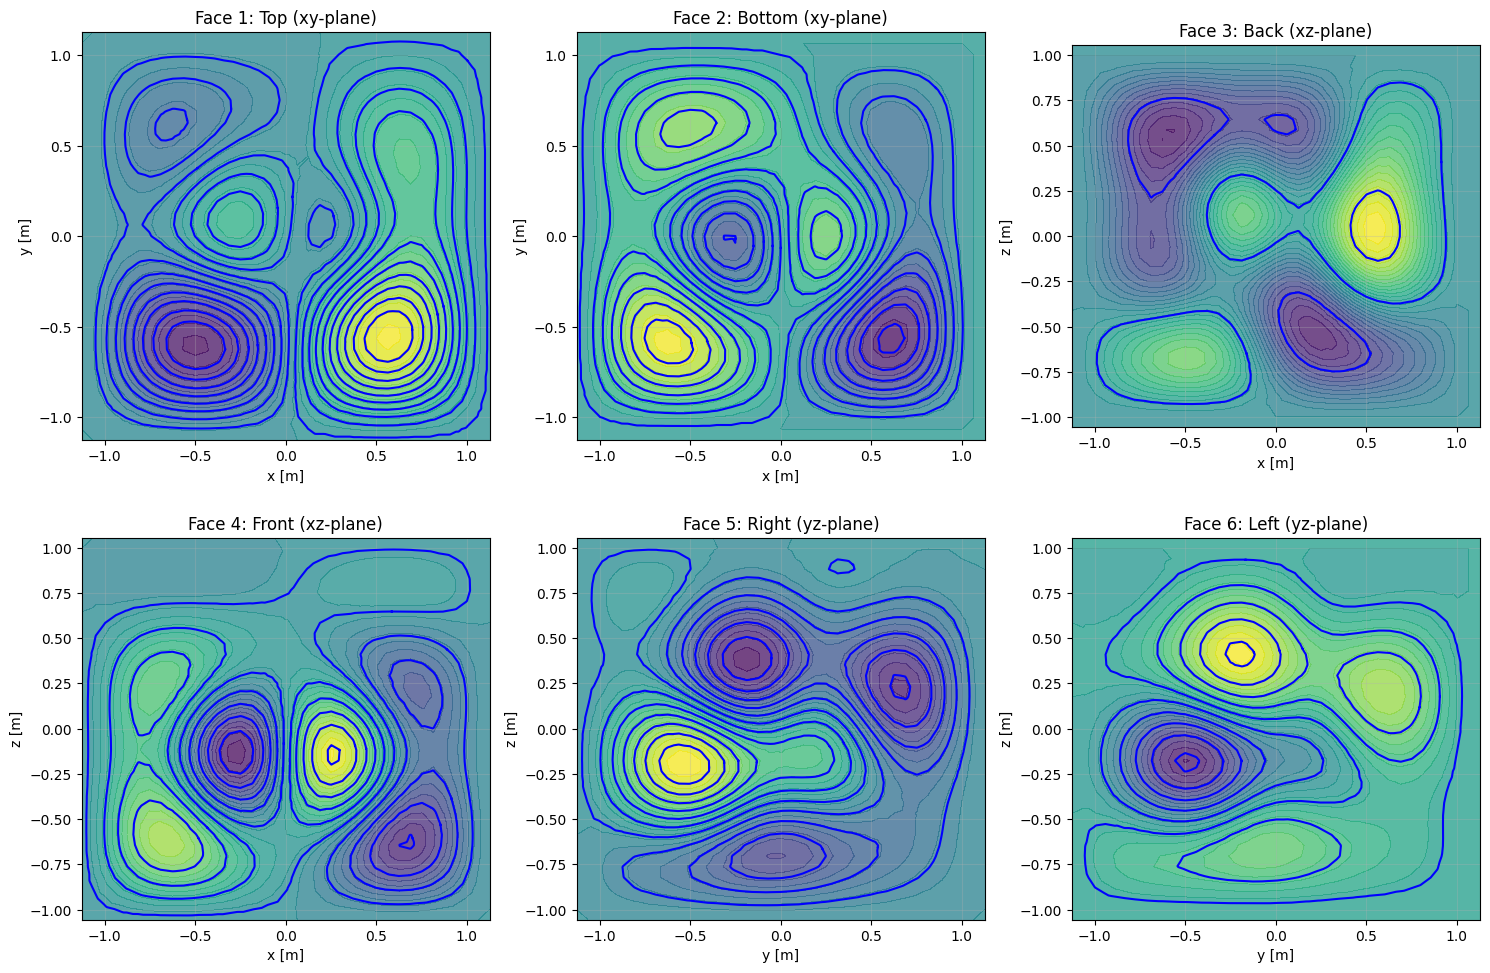

The current which needs to flow in every wire is 0.215 mA.


In [14]:
fkt.plot_contours(all_contours, stream_func_coil, Coils.total_planes.vertices, Steps)

## Smoothen Contour-lines by fft

Procedure:
- Prepare the contours for the fast fourier transform (fft) by repositioning the points that define it to be equally spaced (tuned via fft_resample)
- Run a fast fourier transform (fft) and only keep the dominant frequencies (tuned via fft_keep).
If ```fft_keep``` is a natural number, this amount of hamronics are kept. If ```fft_keep``` is ```None```, the number of harmonics is determined by the equation
\begin{equation}
    fft\_keep = \min\left[\lfloor\frac{n_{points\_resampled}}{2}\rfloor; \max(1; \lfloor\alpha \cdot n_{points\_original}\rfloor)\right]
\end{equation}
- Make the inverse fast fourier transform (ifft) to obtain the smoothened contour lines.

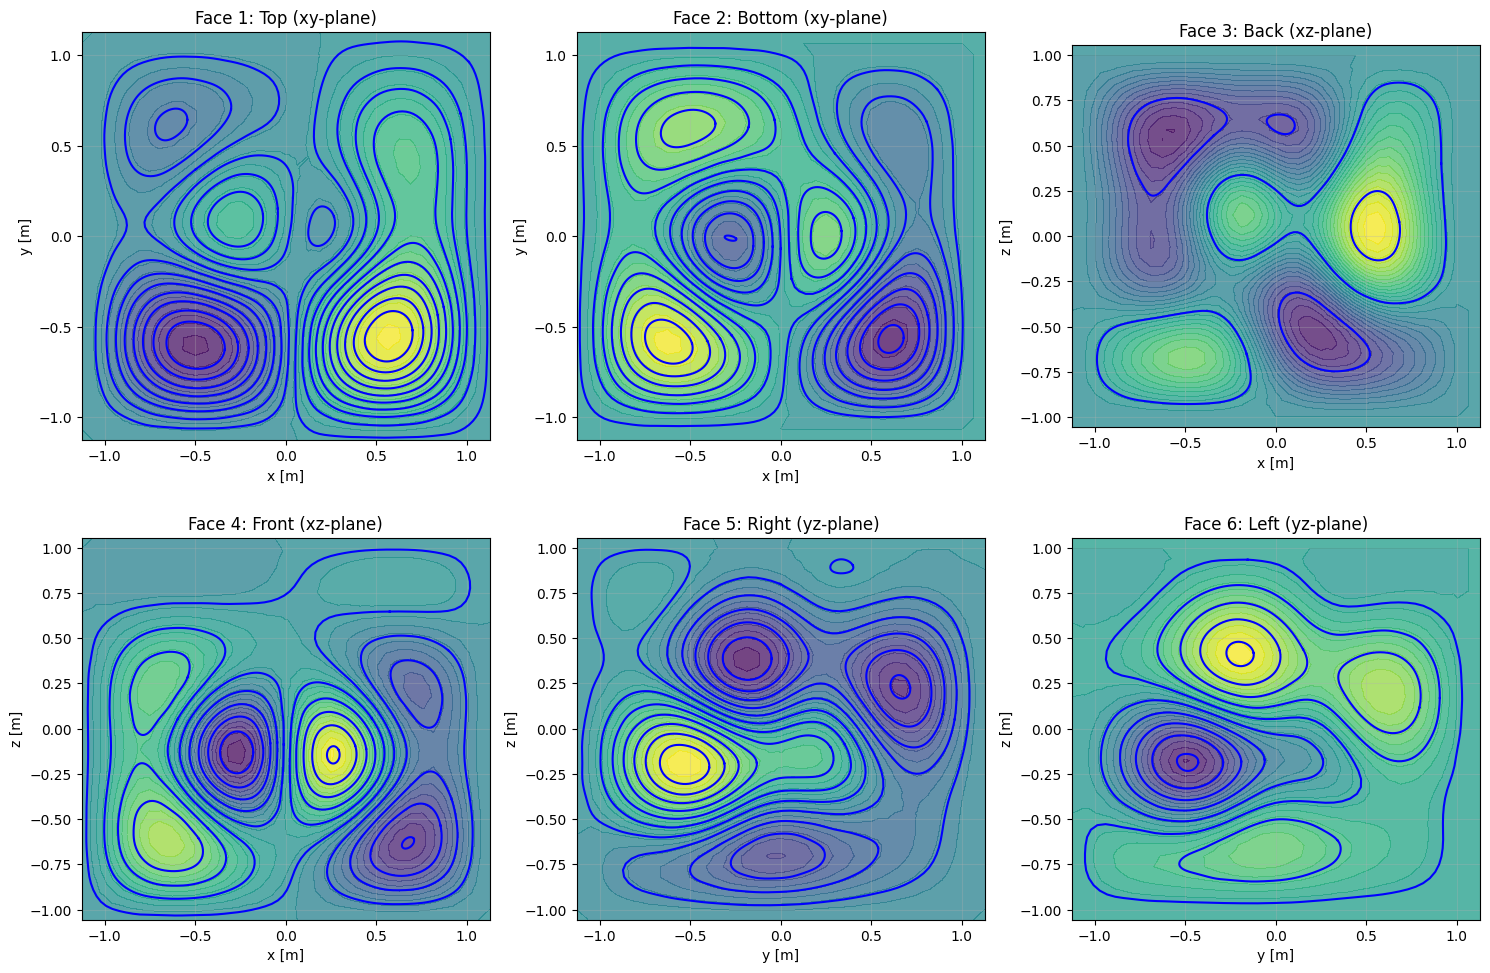

The current which needs to flow in every wire is 0.215 mA.


In [15]:
smoothed_contours = fkt.smooth_all_contours_from_list(
    all_contours,
    n_keep = fft_keep,
    n_resample = fft_resample,
    alpha = fft_alpha
)

fkt.plot_contours(smoothed_contours, stream_func_coil, Coils.total_planes.vertices, Steps)

## Discretise Contours onto square mesh for implementation :(

There are in total 4493 rivets needed, to realise these contours.
Out of 4493 points along the contours, at least 2413 are turn points.


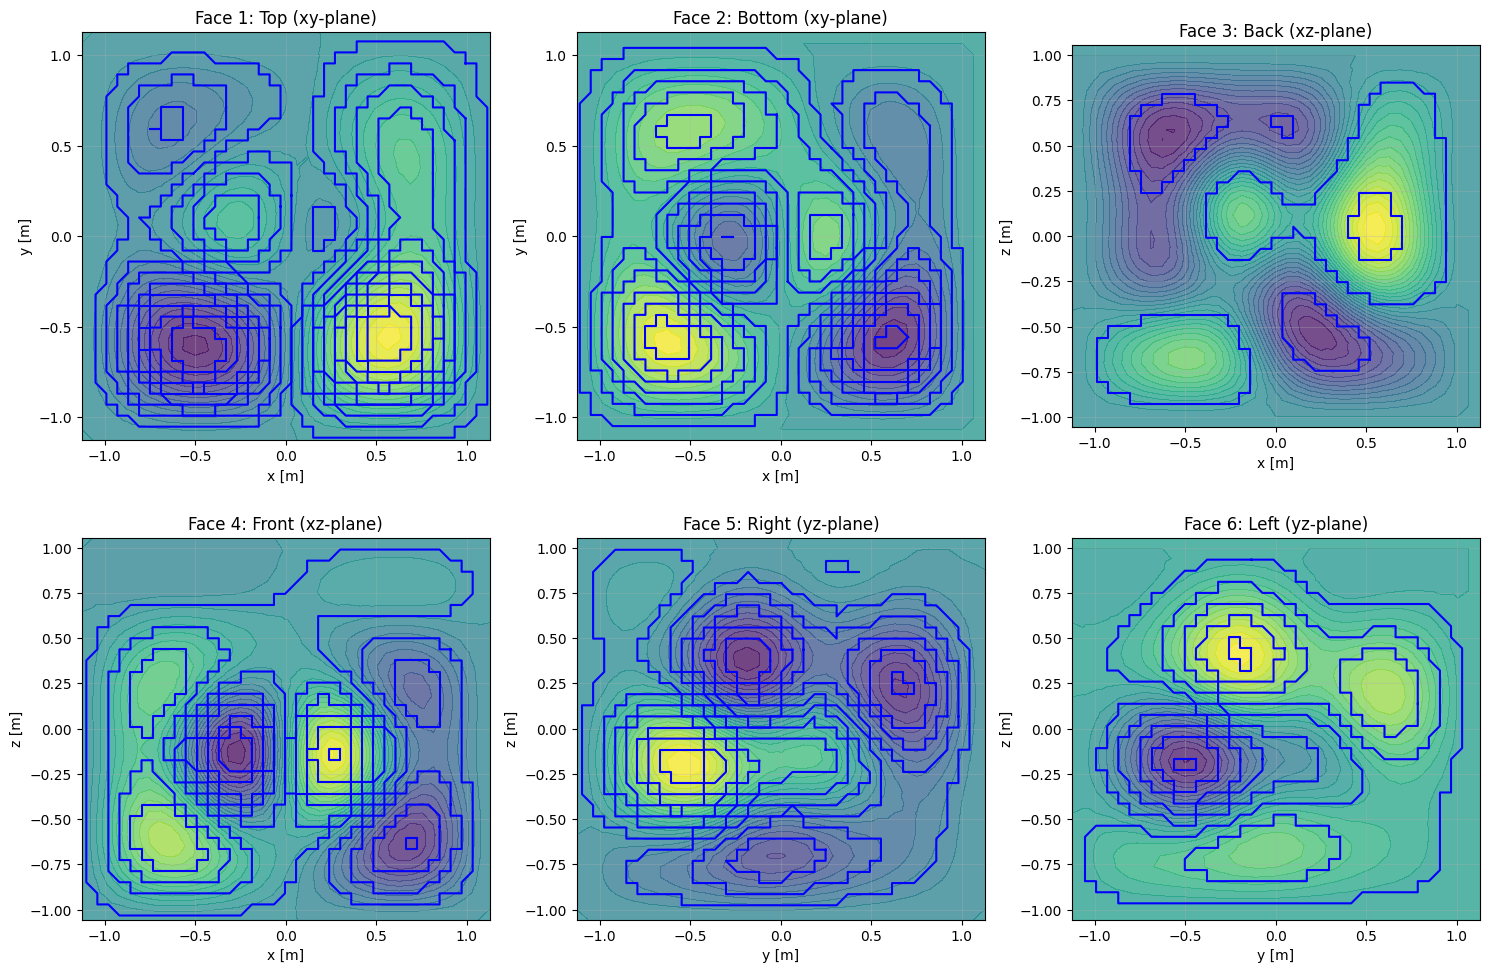

The current which needs to flow in every wire is 0.215 mA.


In [16]:
reconstructed_contours = fkt.build_reconstructed_contours_dynamic(smoothed_contours, spacing)

tot_turns, tot_points = fkt.count_turn_points(reconstructed_contours)
print(f'There are in total {tot_points} rivets needed, to realise these contours.')
print(f'Out of {tot_points} points along the contours, at least {tot_turns} are turn points.')

fkt.plot_contours(reconstructed_contours, stream_func_coil, Coils.total_planes.vertices, Steps)

fkt.plot_contours_per_line_dynamic(reconstructed_contours, stream_func_coil, Coils.total_planes.vertices, Steps, output_dir="single_contour_plots")

## Export Contours for CAD

Export each of the contours in a .txt file named ```xyz_plane_name_curve_index``` with the form

x_1 y_1 z_1

x_2 y_2 z_2


...

The entries are seperated by spaces. The points are seperated by line-breaks. The .txt files are stored in ```D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\Contours```.

These files can later be imported in SolidWorks. To make nice planar sketches, change the constant coordinate to 0!

In [17]:
folder_path_contours = r'D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\Contours'

Face_names = ['Face1_Top_xy', 'Face2_Bottom_xy', 'Face3_Back_xz', 'Face4_Front_xz', 'Face5_Right_yz', 'Face6_Left_yz']

for f in glob.glob(os.path.join(folder_path_contours, "*.txt")):
    os.remove(f)

for face_idx in range(len(smoothed_contours)):
    for contour_idx in range(len(smoothed_contours[face_idx])):
        contour = smoothed_contours[face_idx][contour_idx].copy()

        if face_idx in (0, 1):          # xy-Flächen: z konstant
            contour[:, 2] = 0.0
        elif face_idx in (2, 3):        # xz-Flächen: y konstant
            contour[:, 1] = 0.0
        elif face_idx in (4, 5):        # yz-Flächen: x konstant
            contour[:, 0] = 0.0

        filename = f"{Face_names[face_idx]}_contour{contour_idx + 1}.txt"
        filepath = os.path.join(folder_path_contours, filename)
        np.savetxt(filepath, contour, comments='')

## B-field with mu

First create the stream function from the obtained coil-layup by assigning the analytical values of the stream function to the vertices in the corresponding zones. If
- the vertex is within a closed loop (and the sign is positive!): Write Streamfunctionvalue of $n_{loops\_within} \cdot I_{per\_loop}$ to the vertex.
- the vertex is exactly on a closed loop: Write the average value of the Streamfunction between both adjacent zones to the vertex.
- the vertex is inside no loop: Write the value 0 to the vertex


Starting create_coil_stream_function
target_vertices shape: (8214, 3)
wire_positions has 6 faces
contour_is_positive has 6 faces


PROCESSING FACE 1
  Number of contours on this face: 24
  Contour booleans (current sign): [np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]
  Normal axis: 2 (x=0, y=1, z=2)
  Constant coordinate value: 1.1055 m
  Variance along axes: x=3.7e-01, y=3.2e-01, z=2.1e-28
  2D contours extracted: 24 which all have length 21

  Vertices on this face: 1369 out of 8214

  Face 1: 960 vertices got non-zero values


PROCESSING FACE 2
  Number of contours on this face: 24
  Contour booleans (current sign): [np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.True_, np.True_, np.True_, np.True_, np.T

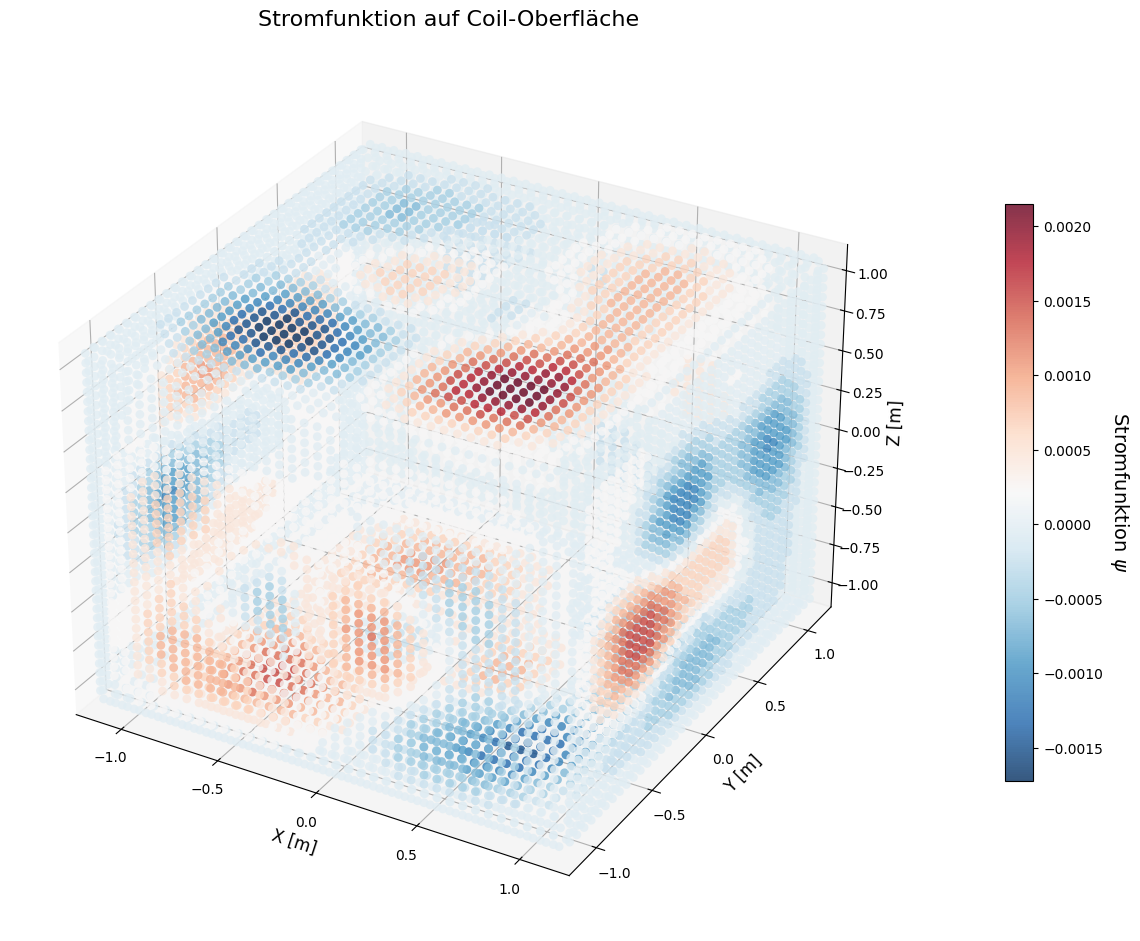

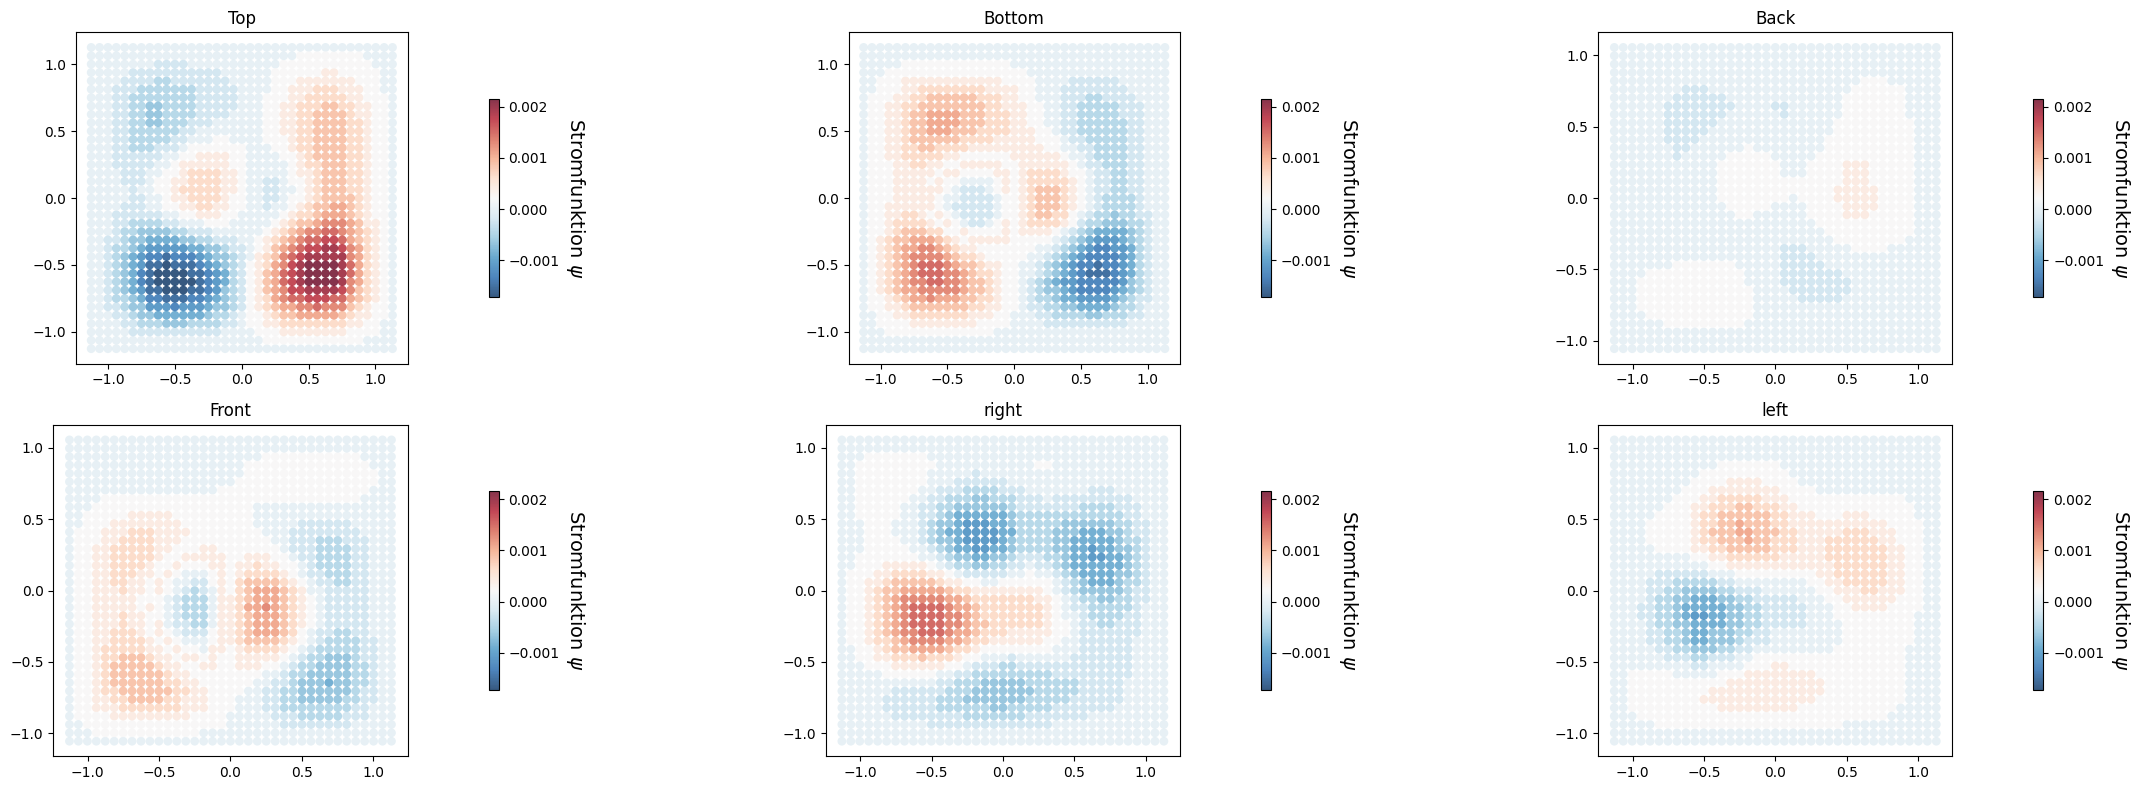

In [18]:
current_per_wire = (stream_func_coil.max() - stream_func_coil.min()) / Steps

stream_func_nulling, vertices_with_values = fkt.create_coil_stream_function(
    wire_positions = reconstructed_contours, # smoothed_contours
    contour_is_positive = contour_is_positive,
    current = current_per_wire,
    target_vertices = Coils.total_planes.vertices
)

# Final summary
print(f"\n{'='*60}")
print(f"FINAL SUMMARY")
print(f"{'='*60}")

nonzero_vertices = np.sum(stream_func_nulling != 0)
print(f"Total vertices with non-zero stream function: {nonzero_vertices} out of {len(Coils.total_planes.vertices)}")

# Check which vertices were written multiple times
multi_write_vertices = np.sum(vertices_with_values > 1)
print(f"Vertices written by multiple faces: {multi_write_vertices}")

if multi_write_vertices > 0:
    print(f"\n  WARNING: These vertices got written by multiple faces!")
    print(f"  This means vertices are on the EDGE between faces (corner vertices)")

# Show vertices count per face
print(f"\n  Vertices per face (from mask):")
for face_idx in range(6):
    face_contours = reconstructed_contours[face_idx] # smoothed_contours[face_idx]
    if len(face_contours) == 0:
        print(f"    Face {face_idx}: NO CONTOURS")
        continue
    
    all_points_face = []
    for contour in face_contours:
        for pt in contour:
            all_points_face.append(pt)
    all_points_face = np.array(all_points_face)
    normal_axis = np.argmin(np.var(all_points_face, axis=0))
    const_coord = all_points_face[0, normal_axis]
    
    face_vertices_mask = np.abs(Coils.total_planes.vertices[:, normal_axis] - const_coord) < 1e-6
    print(f"    Face {face_idx+1}: normal_axis={normal_axis}, const={const_coord:.6f}, vertices={np.sum(face_vertices_mask)}")

print(f"{'='*60}\n")

fkt.plot_stream_function(Coils.total_planes.vertices, stream_func_nulling)

## $B$-field by cake approximation
After obtaining the stream function, calculate the $B$-field by:

$B_{nulling} = C \cdot \psi$

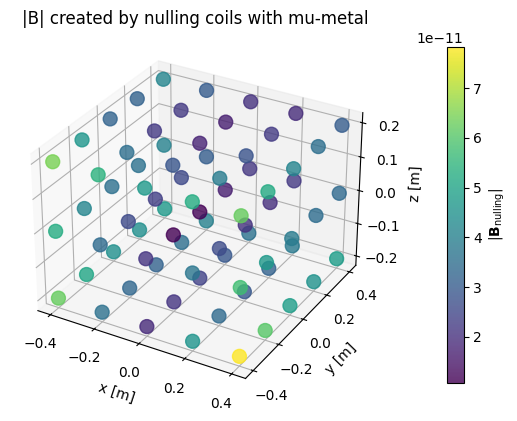

In [19]:
B_nulling_flat = total_Coupling_flat @ stream_func_nulling

n = int(len(B_nulling_flat) / 3)
B_nulling = B_nulling_flat.reshape(n, 3)

# Plots
fig_B_nulling = plt.figure()
ax_B_nulling = fig_B_nulling.add_subplot(111, projection='3d')
sc_B_nulling = ax_B_nulling.scatter(
    target_point_coord_exp[:, 0],
    target_point_coord_exp[:, 1],
    target_point_coord_exp[:, 2],
    c=np.linalg.norm(B_nulling, axis=1),
    s=100,
    cmap='viridis',
    alpha = 0.8,
)
ax_B_nulling.set_xlabel('x [m]')
ax_B_nulling.set_ylabel('y [m]')
ax_B_nulling.set_zlabel('z [m]')
ax_B_nulling.set_title('|B| created by nulling coils with mu-metal')
cbar = fig_B_nulling.colorbar(sc_B_nulling, ax=ax_B_nulling, label=r'$|\mathbf{B}_{\text{nulling}}|$')
cbar.ax.set_position([0.85, 0.15, 0.03, 0.7])

## Check contours with Biot-Savart

Use the law of Biot-Savart to calculate the B-field due to the coil layup along the contour lines.

\begin{equation}
    \mathbf{B}(\mathbf{r}) = \frac{\mu_0}{4\pi} \int \frac{I \, \text{d}\ell \times (\mathbf{r} - \mathbf{r}')}{|\mathbf{r} - \mathbf{r}'|^3} \Rightarrow \text{d}{\bf{B}} = \frac{{\mu _0 }}{{4\pi }}\frac{{I \text{d}\ell \times {\bf{\hat R}}}}{{R^2 }}
\end{equation}

**Note**: This calculates the B-field, as if there was no mu-metal!

In [20]:
if False:
    B_biot_savart = fkt.biot_savart_from_contours(smoothed_contours, target_point_coord_exp, current_per_wire)

    # Plots
    fig_B_biot_savart = plt.figure()
    ax_B_biot_savart = fig_B_biot_savart.add_subplot(111, projection='3d')
    sc_B_biot_savart = ax_B_biot_savart.scatter(
        target_point_coord_exp[:, 0],
        target_point_coord_exp[:, 1],
        target_point_coord_exp[:, 2],
        c=np.linalg.norm(B_biot_savart, axis=1),
        s=100,
        cmap='viridis',
        alpha = 0.8,
    )
    ax_B_biot_savart.set_xlabel('x [m]')
    ax_B_biot_savart.set_ylabel('y [m]')
    ax_B_biot_savart.set_zlabel('z [m]')
    ax_B_biot_savart.set_title('|B| created by nulling coils without mu-metal')
    cbar = fig_B_biot_savart.colorbar(sc_B_biot_savart, ax=ax_B_biot_savart, label=r'$|\mathbf{B}_{\text{nulling}}|$')
    cbar.ax.set_position([0.85, 0.15, 0.03, 0.7])

# Evaluation

Make nice plots and Sanity checks here!

## Difference: Experiment vs. Nulling-field

$B_{diff} = B_{exp} - B_{nulling}$

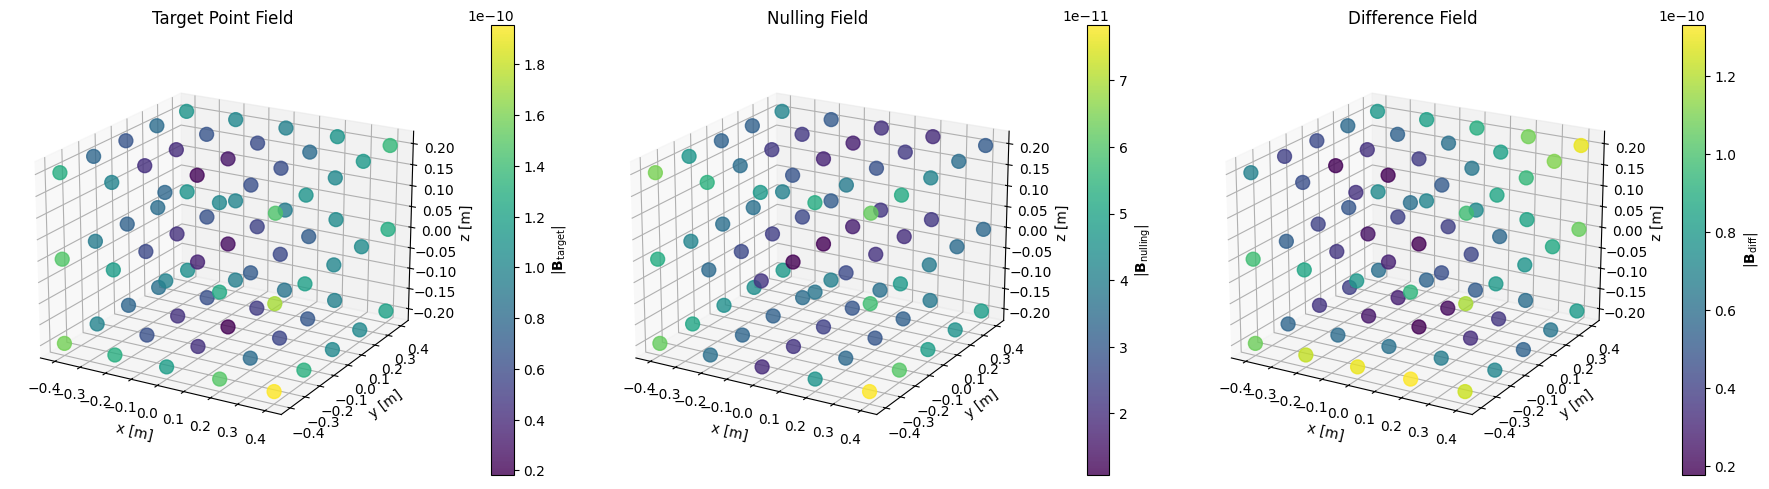

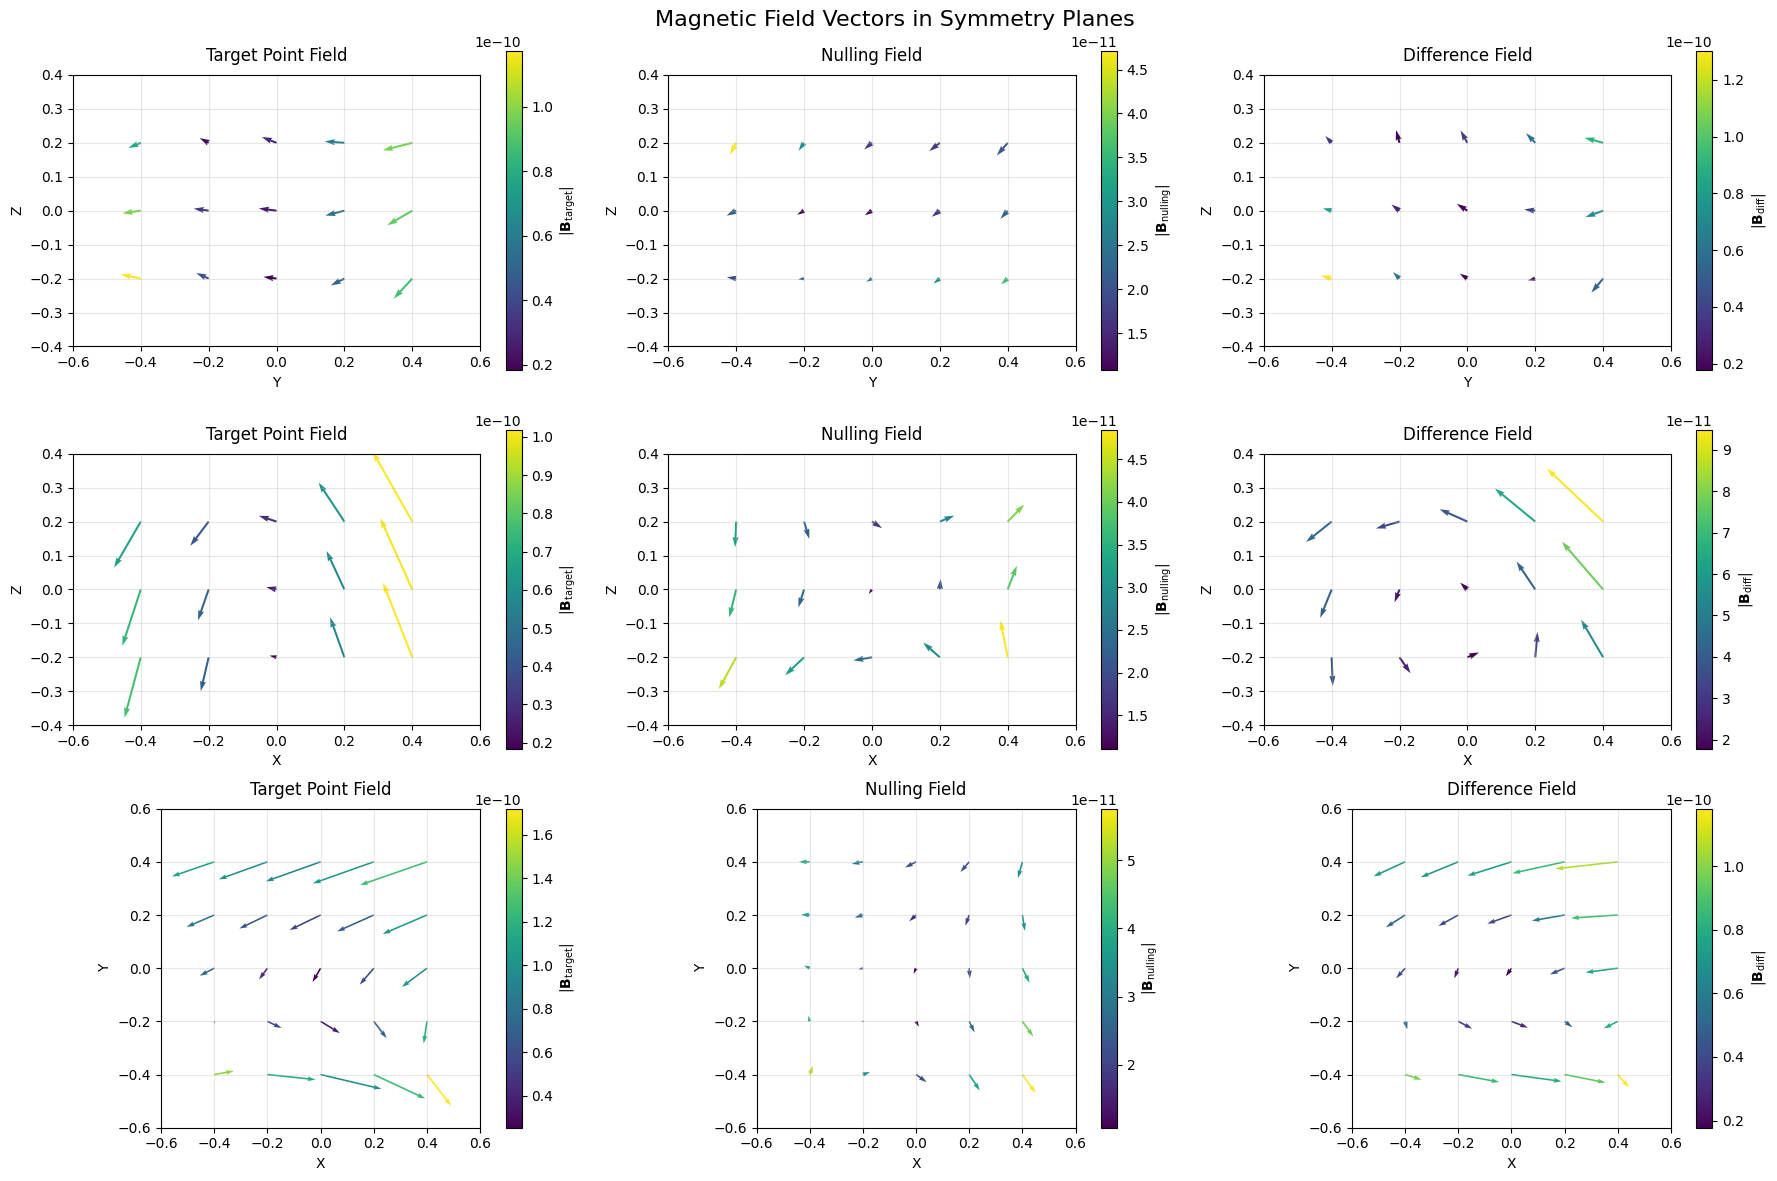

The RMS-value of the measured field is: RMS = 96.11 pT
The RMS-value of the nulling field is: RMS = 38.10 pT
The RMS-value of the difference betweeen measured field and nulling field is: RMS = 71.27 pT
This means that the background field is reduced by 25.84 %


In [21]:
B_diff = B_target_point_exp - B_nulling

# Plots
# Create figure with 3 subplots side by side
fig = plt.figure(figsize=(18, 5))

# Define the three fields with their titles and colorbar labels
fields = [
    (B_target_point_exp, r'$|\mathbf{B}_{\text{target}}|$', 'Target Point Field'),
    (B_nulling, r'$|\mathbf{B}_{\text{nulling}}|$', 'Nulling Field'),
    (B_diff, r'$|\mathbf{B}_{\text{diff}}|$', 'Difference Field')
]

# Create three 3D subplots
for i, (B_field, colorbar_label, title) in enumerate(fields):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Calculate norm of the magnetic field
    field_norm = np.linalg.norm(B_field, axis=1)
    
    # Create scatter plot
    sc = ax.scatter(
        target_point_coord_exp[:, 0],
        target_point_coord_exp[:, 1],
        target_point_coord_exp[:, 2],
        c=field_norm,
        s=100,
        cmap='viridis',
        alpha=0.8
    )
    
    # Add title to subplot
    ax.set_title(title, pad=10)
    
    # Add colorbar with padding to move it to the right
    cbar = fig.colorbar(sc, ax=ax, label=colorbar_label, pad=0.1)
    
    # Set axis labels
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    
    # Optional: Adjust 3D view angle for better visualization
    ax.view_init(elev=20, azim=-60)

plt.tight_layout()

# ===== DATA FILTERING: Extract points on each symmetry plane =====
def filter_plane(target_point, B_field, plane_coord, tolerance=1e-5):
    """Filter points on a symmetry plane and return 2D positions + 2D vectors"""
    # Find indices where the coordinate is close to 0
    mask = np.isclose(target_point[:, plane_coord], 0, atol=tolerance)
    
    # Extract filtered data
    target_filtered = target_point[mask]
    B_filtered = B_field[mask]
    
    return target_filtered, B_filtered, mask

# Filter data for each symmetry plane
# X=0 plane (YZ plane) - show Y vs Z, vectors: B_y, B_z
target_X0, B_target_X0, _ = filter_plane(target_point_coord_exp, B_target_point_exp, 0)
target_X0_null, B_null_X0, _ = filter_plane(target_point_coord_exp, B_nulling, 0)
target_X0_diff, B_diff_X0, _ = filter_plane(target_point_coord_exp, B_diff, 0)

# Y=0 plane (XZ plane) - show X vs Z, vectors: B_x, B_z
target_Y0, B_target_Y0, _ = filter_plane(target_point_coord_exp, B_target_point_exp, 1)
target_Y0_null, B_null_Y0, _ = filter_plane(target_point_coord_exp, B_nulling, 1)
target_Y0_diff, B_diff_Y0, _ = filter_plane(target_point_coord_exp, B_diff, 1)

# Z=0 plane (XY plane) - show X vs Y, vectors: B_x, B_y
target_Z0, B_target_Z0, _ = filter_plane(target_point_coord_exp, B_target_point_exp, 2)
target_Z0_null, B_null_Z0, _ = filter_plane(target_point_coord_exp, B_nulling, 2)
target_Z0_diff, B_diff_Z0, _ = filter_plane(target_point_coord_exp, B_diff, 2)

# ===== CREATE 3x3 GRID OF 2D VECTOR PLOTS =====
fig = plt.figure(figsize=(18, 12))

# Define fields with their titles and colorbar labels
fields = [
    (B_target_point_exp, target_X0, B_target_X0, target_Y0, B_target_Y0, target_Z0, B_target_Z0, 
     r'$|\mathbf{B}_{\text{target}}|$', 'Target Point Field'),
    (B_nulling, target_X0_null, B_null_X0, target_Y0_null, B_null_Y0, target_Z0_null, B_null_Z0,
     r'$|\mathbf{B}_{\text{nulling}}|$', 'Nulling Field'),
    (B_diff, target_X0_diff, B_diff_X0, target_Y0_diff, B_diff_Y0, target_Z0_diff, B_diff_Z0,
     r'$|\mathbf{B}_{\text{diff}}|$', 'Difference Field')
]

# Define planes with their axis configurations
planes = [
    ('X=0 (YZ)', 1, 2, 'Y', 'Z', 0),   # Show Y vs Z, vectors: B_y, B_z
    ('Y=0 (XZ)', 0, 2, 'X', 'Z', 1),   # Show X vs Z, vectors: B_x, B_z
    ('Z=0 (XY)', 0, 1, 'X', 'Y', 2)    # Show X vs Y, vectors: B_x, B_y
]

# Create 3x3 subplots
for row, (plane_name, coord1, coord2, axis1_label, axis2_label, plane_coord) in enumerate(planes):
    for col, (B_field, target_X, B_X, target_Y, B_Y, target_Z, B_Z, colorbar_label, title) in enumerate(fields):
        ax = fig.add_subplot(3, 3, row*3 + col + 1)
        
        # Select data for this plane
        if row == 0:  # X=0 plane
            target_plot, B_plot = target_X, B_X
        elif row == 1:  # Y=0 plane
            target_plot, B_plot = target_Y, B_Y
        else:  # Z=0 plane
            target_plot, B_plot = target_Z, B_Z
        
        # Extract 2D coordinates and vector components
        x_plot = target_plot[:, coord1]
        y_plot = target_plot[:, coord2]
        u = B_plot[:, coord1]  # Vector component in coord1 direction
        v = B_plot[:, coord2]  # Vector component in coord2 direction
        
        # Create 2D quiver (vector) plot
        q = ax.quiver(x_plot, y_plot, u, v, np.linalg.norm(B_plot, axis=1),
              cmap='viridis', scale=0.5*10**(-9), scale_units='width', width=0.005)
        
        xmin, xmax = x_plot.min() - 0.2, x_plot.max() + 0.2
        ymin, ymax = y_plot.min() - 0.2, y_plot.max() + 0.2
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        # Add colorbar
        cbar = plt.colorbar(q, ax=ax, label=colorbar_label)
        
        # Add title and axis labels
        ax.set_title(title, pad=10)
        ax.set_xlabel(axis1_label)
        ax.set_ylabel(axis2_label)
        ax.set_aspect('equal')
        
        # Add grid
        ax.grid(True, alpha=0.3)

plt.suptitle('Magnetic Field Vectors in Symmetry Planes', fontsize=16)
plt.tight_layout()
plt.show()

rms_exp = np.sqrt((1/len(B_target_point_exp)) * np.sum((np.linalg.norm(B_target_point_exp) * 10**(12))**2))
rms_nulling = np.sqrt((1/len(B_nulling)) * np.sum((np.linalg.norm(B_nulling) * 10**(12))**2))
rms_error = np.sqrt((1/len(B_diff)) * np.sum((np.linalg.norm(B_diff) * 10**(12))**2))
print(f'The RMS-value of the measured field is: RMS = {rms_exp:.2f} pT')
print(f'The RMS-value of the nulling field is: RMS = {rms_nulling:.2f} pT')
print(f'The RMS-value of the difference betweeen measured field and nulling field is: RMS = {rms_error:.2f} pT')
print(f'This means that the background field is reduced by {(1 - (rms_error/rms_exp)) * 100:.2f} %')

## Singular spectrum analysis

The singular value analysis looks at the relative magnitude of the diagonal entries of the SVD of the matrix in question. The SVD is formulated as
\begin{equation}
    \mathbf{M} = \mathbf{U\Sigma V}^*
\end{equation}
where $\mathbf{\Sigma}$ is a diagonal matrix $\text{diag}[\sigma_0, \sigma_1, ...]$.
In the singular spectrum analysis we examine the relative sizes $\frac{\sigma_i}{\sigma_{max}}$ of this middle matrix of the SVD. We look for

- early dropping magnitudes indicate a ill-conditioned problem, where only few parameters can be resolved nicely in the inverse probem and many parameters increase noise sensitivity of the solution.
- many equally high diagonal entries and only few small one which can be recognised by a long initial plateau in the logarithmic plot. This indicates, that many parameters can be resolved nicely in the inverse problem and noise sensitivity is low.

https://en.wikipedia.org/wiki/Singular_spectrum_analysis

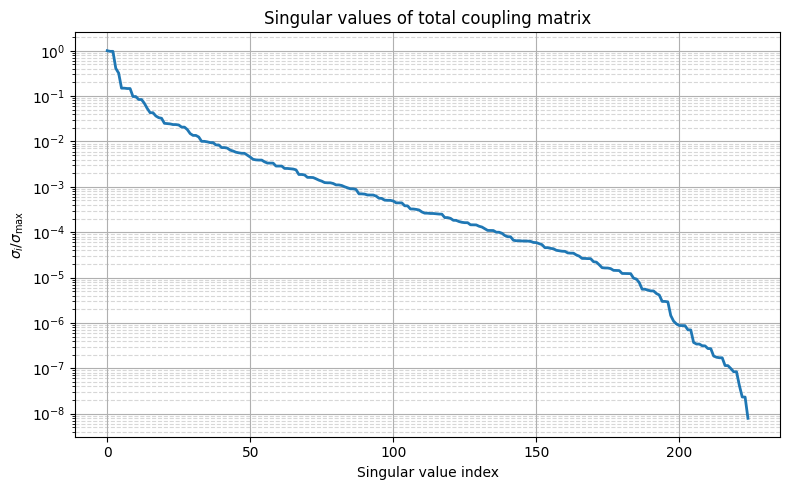

3.4374393710507524e+19


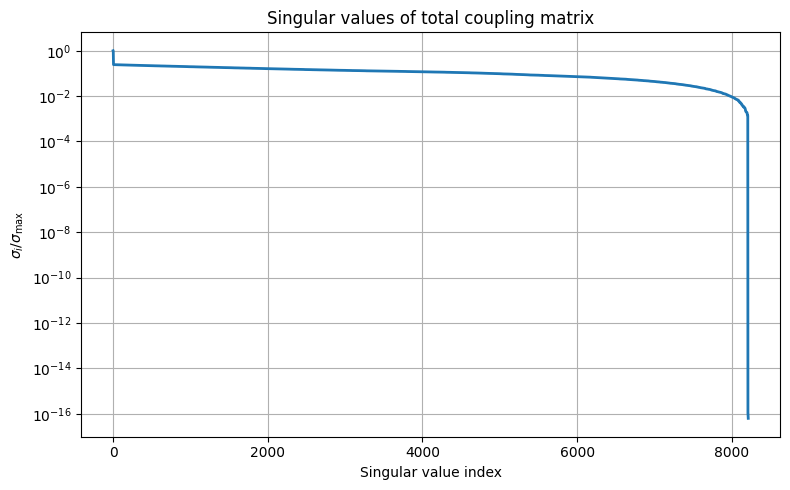

In [22]:
# Singular spectrum analysis of the original problem
fkt.plot_singular_values(total_Coupling_flat, normalize=True, log_scale=True)

# print characteristic value of A (matrix used in regularisation) to compare to Chiara
A_dense = A.toarray() if hasattr(A, "toarray") else A
cond_A = np.linalg.cond(A_dense)
print(cond_A)

# Find the equivalent matrix describing the problem after regularisation
L_dense = L_sparse.todense()
C_aug = np.vstack([Coupling_coil_flat, np.sqrt(lam_lap) * L_dense])

fkt.plot_singular_values(C_aug, normalize=True, log_scale=True)

## Error distributions

Histogramm comparing the magnitude of error in each component of $B$ as well as the norm of $B$. Just as Chiara did them to be compareable

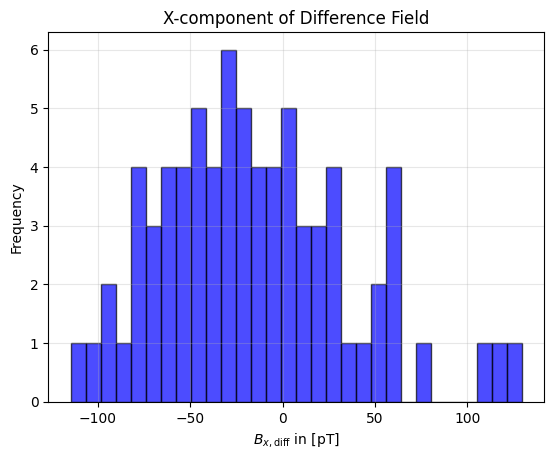

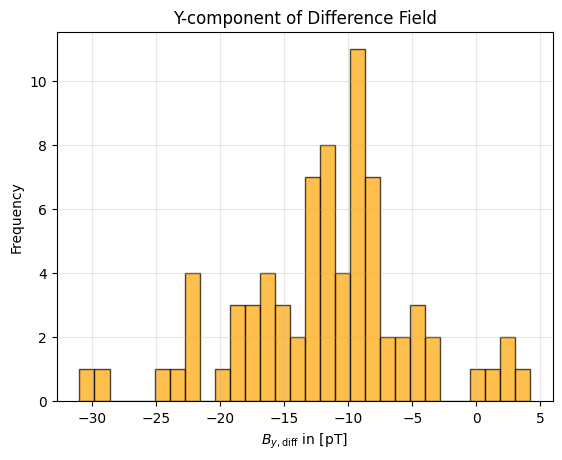

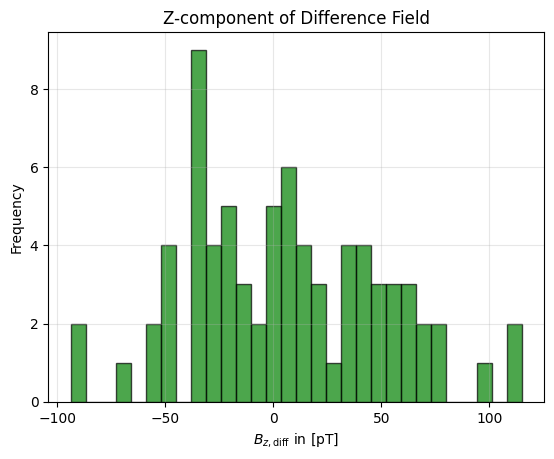

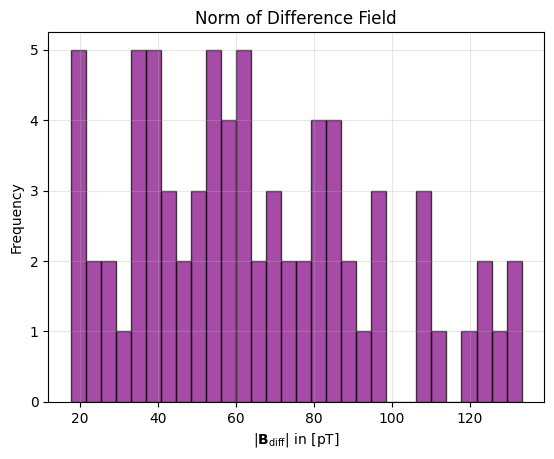

In [23]:
B_x_diff = B_diff[:, 0] * 10**(12)
B_y_diff = B_diff[:, 1] * 10**(12)
B_z_diff = B_diff[:, 2] * 10**(12)
B_norm_diff = np.linalg.norm(B_diff, axis = 1) * 10**(12)

bins = 30

# Plot 1: B_x_diff
plt.figure()
plt.hist(B_x_diff, bins, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$B_{x,\text{diff}}$ in [pT]')
plt.ylabel('Frequency')
plt.title('X-component of Difference Field')
plt.grid(alpha=0.3)
plt.show()

# Plot 2: B_y_diff
plt.figure()
plt.hist(B_y_diff, bins, color='orange', edgecolor='black', alpha=0.7)
plt.xlabel(r'$B_{y,\text{diff}}$ in [pT]')
plt.ylabel('Frequency')
plt.title('Y-component of Difference Field')
plt.grid(alpha=0.3)
plt.show()

# Plot 3: B_z_diff
plt.figure()
plt.hist(B_z_diff, bins, color='green', edgecolor='black', alpha=0.7)
plt.xlabel(r'$B_{z,\text{diff}}$ in [pT]')
plt.ylabel('Frequency')
plt.title('Z-component of Difference Field')
plt.grid(alpha=0.3)
plt.show()

# Plot 4: B_norm_diff
plt.figure()
plt.hist(B_norm_diff, bins, color='purple', edgecolor='black', alpha=0.7)
plt.xlabel(r'$|\mathbf{B}_{\text{diff}}|$ in [pT]')
plt.ylabel('Frequency')
plt.title('Norm of Difference Field')
plt.grid(alpha=0.3)
plt.show()

## Single plane fields

What Chiara suggested